 equação de estado cúbica: gás ideal vs fluido real

# Modelagem de propriedades PVT com a equação de Peng–Robinson

Este notebook implementa a equação de estado de Peng–Robinson em Python para calcular o fator de compressibilidade Z e o volume molar de hidrocarbonetos típicos da indústria do petróleo em função da pressão e da temperatura. O objetivo é analisar o desvio em relação ao gás ideal e discutir aplicações em engenharia de petróleo.

Proposta em 1976 como uma forma simples e relativamente precisa de descrever o comportamento PVT de fluidos reais, em especial hidrocarbonetos utilizados na indústria de petróleo, a forma original da equação é:

\[
P = \frac{RT}{V - b} - \frac{a(T)}{V(V + b) + b(V - b)}
\]

em que \(P\) é a pressão, \(T\) a temperatura, \(V\) o volume molar, \(R\) a constante universal dos gases, e \(a(T)\), \(b\) são parâmetros obtidos a partir das propriedades críticas e do fator acêntrico (definido e introduzido pelo físico-químico Kenneth Pitzer em 1955 em que mede a  de cada componentenão-esfericidade (acentricidade) das moléculas, servindo como um parâmetro de correção para o Teorema dos Estados Correspondentes).

In [101]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

R = 8.314  # constante universal dos gases em J/mol.K

In [102]:
# Funções auxiliares para a equação de estado de Peng–Robinson

def pr_params(Tc, Pc, omega, T, P):
    """
    Calcula os parâmetros adimensionais A e B da equação de Peng–Robinson
    a partir de propriedades críticas (Tc, Pc), fator acêntrico (omega),
    temperatura (T) e pressão (P).
    """
    Tr = T / Tc  # temperatura reduzida
    # Parâmetro de correção (função alfa) em função do fator acêntrico
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    alpha = (1 + kappa*(1 - np.sqrt(Tr)))**2

    # Parâmetros a(T) e b da EoS (forma clássica)
    a = 0.45724 * (R**2 * Tc**2 / Pc) * alpha
    b = 0.07780 * (R * Tc / Pc)

    # Parâmetros adimensionais A e B usados na equação cúbica em Z
    A = a * P / (R**2 * T**2)
    B = b * P / (R * T)
    return A, B


def pr_Z_roots(A, B):
    """
    Monta e resolve o polinômio cúbico em Z da equação de Peng–Robinson.
    Retorna as três raízes (podem ser reais ou complexas).
    """
    coef = [1.0,
            -(1 - B),
            (A - 2*B - 3*B**2),
            -(A*B - B**2 - B**3),
            ]
    Z = np.roots(coef)
    return Z


def pr_Z_fisico(A, B):
    """
    Seleciona a raiz real de Z. 
   Isto é, em regiões de transição, este modelo seleciona a maior raiz (fase vapor) 
    para simplificação da análise de compressibilidade.
    """
    Z = pr_Z_roots(A, B)
    Z_real = Z[np.isreal(Z)].real
    Z_valido = Z_real[Z_real > B]
    return np.max(Z_valido) if len(Z_valido) > 0 else np.nan



In [103]:
# Propriedades críticas e fator acêntrico de alguns hidrocarbonetos
# típicos da indústria do petróleo (gás natural e frações leves)

fluidos = {
    "metano":   {"Tc": 190.6, "Pc": 4.60e6, "omega": 0.011},
    "etano":    {"Tc": 305.3, "Pc": 4.88e6, "omega": 0.099},
    "propano":   {"Tc": 369.8, "Pc": 4.25e6, "omega": 0.152},
    "n-butano": {"Tc": 425.2, "Pc": 3.80e6, "omega": 0.193},
    "n-pentano":{"Tc": 469.7, "Pc": 3.37e6, "omega": 0.251},
    "n-hexano": {"Tc": 507.6, "Pc": 3.04e6, "omega": 0.301},
    "n-heptano":{"Tc": 540.2, "Pc": 2.74e6, "omega": 0.349},
    "n-octano": {"Tc": 568.7, "Pc": 2.49e6, "omega": 0.399},
}

# Estou usando uma lista simplificada de componentes puros representativos das frações leves do petróleo (C1–C8)
# Em aplicações reais, o petróleo é tratado como mistura de muitos componentes ou pseudocomponentes (C7+, frações pesadas)
# Mesmo assim, o mesmo modelo de Peng–Robinson se aplica via regras de mistura

In [104]:
# Escolha do fluido a ser estudado (edite o nome aqui)
fluido_escolhido = "n-octano"  # altere para "etano", "propan", "n-butano", "n-hexano" ou outro da lista  

if fluido_escolhido not in fluidos:
    raise ValueError("Fluido não cadastrado. Escolha um da lista de 'fluidos'.")

props = fluidos[fluido_escolhido]
Tc = props["Tc"]
Pc = props["Pc"]
omega = props["omega"]

print(f"Usando {fluido_escolhido} com Tc={Tc} K, Pc={Pc/1e6:.2f} MPa, ω={omega}")


Usando n-octano com Tc=568.7 K, Pc=2.49 MPa, ω=0.399


Para multi-temperaturas,  cada linha do df representa um estado termodinâmico do fluido (um par pressão–temperatura), com as propriedades calculadas.

In [105]:
# Cálculo do fator Z em função da pressão para várias temperaturas

# Definindo temperaturas de estudo: 0,8 Tc, Tc e 1,2 Tc
T_vals = [0.8*Tc, 1.0*Tc, 1.2*Tc]
P_vals = np.linspace(1e5, 1.0e7, 200)  

# Cálculo do parâmetro b real 
b_real = 0.07780 * (R * Tc / Pc)

linhas = []
for T in T_vals:
    for P in P_vals:
        A, B = pr_params(Tc, Pc, omega, T, P)
        Z = pr_Z_fisico(A, B)
        Vm = Z * R * T / P

        # Verificação física: o volume molar não pode ser menor que o volume das moléculas (b)
        if Vm < b_real:
            print(f"Aviso: Condição instável detectada em {T}K e {P/1e5:.1f} bar")
        pass

        linhas.append({
            "fluido": fluido_escolhido,
            "T_K": T,
            "P_Pa": P,
            "Z": Z,
            "Vm_m3mol": Vm
        })

df = pd.DataFrame(linhas)
df.head()


,fluido,T_K,P_Pa,Z,Vm_m3mol
0,n-octano,454.96,100000.000000,0.968489,0.036633
1,n-octano,454.96,149748.743719,0.952246,0.024053
2,n-octano,454.96,199497.487437,0.935579,0.017739
3,n-octano,454.96,249246.231156,0.918445,0.013938
4,n-octano,454.96,298994.974874,0.900796,0.011396


Explicando as colunas:

*fluido: nome do componente que você escolheu (metano, etano, etc.).

* T_K: temperatura em kelvin usada naquele cálculo (0,8 Tc, Tc ou 1,2 Tc).

* P_Pa: pressão em pascal (entre 1x10^5 Pa e 1x10^7 Pa).

* Z: fator de compressibilidade calculado pela Peng–Robinson para aquele par (P, T).

Se fosse gás ideal, seria Z=1;

Z<1 indica forças atrativas predominando; 

Z>1, repulsivas.

* Vm_m3mol: volume molar correspondente, calculado por Vm= Z \frac{RT}{P}

In [106]:


df_plot = df.copy()
df_plot["P_bar"] = df_plot["P_Pa"] / 1e5
df_plot["T_label"] = df_plot["T_K"].round(1).astype(str) + " K"

fig = px.line(
    df_plot,
    x="P_bar",
    y="Z",
    color="T_label",
    title=f"Fator de compressibilidade Z vs pressão para {fluido_escolhido} (Peng–Robinson)",
    labels={"P_bar": "Pressão (bar)", "Z": "Fator de compressibilidade", "T_label": "Temperatura"}
)
fig.show()


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\plotly\express\_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



#  Comparação: Peng-Robinson vs Gás Ideal

Análise comparativa entre o modelo de gás ideal e a equação de Peng-Robinson para hidrocarbonetos de cadeia curta sob altas pressões.

Análise de Desvio de IdealidadeA seguir, quantificamos o erro relativo do modelo de gás ideal frente à equação de Peng-Robinson. Esta análise é crítica para o dimensionamento de compressores e vasos de separação, onde o fator $Z$ dita o volume real ocupado pelo gás sob alta pressão.

### Por que isso importa:
Gás Ideal: V_m = RT/P ✅ simples, mas irreal

Gás Real: V_m = Z·RT/P ✅ Z<1 = comprimível (petróleo!)

**Expectativa**: \(V_m^{PR} < V_m^{ideal}\) (forças intermoleculares)

In [107]:
# Comparação metano (PR) vs gás ideal
df_ideal = df.copy()
df_ideal["Z_ideal"] = 1.0
df_ideal["Vm_ideal_m3mol"] = (df_ideal["Z_ideal"] * R * df_ideal["T_K"]) / df_ideal["P_Pa"]
df_ideal["P_bar"] = df_ideal["P_Pa"] / 1e5
df_ideal["Vm_Lmol"] = df_ideal["Vm_m3mol"] * 1000
df_ideal["Vm_ideal_Lmol"] = df_ideal["Vm_ideal_m3mol"] * 1000

# Filtrar pressões específicas (1, 50, 100 bar)
df_comp = df_ideal[df_ideal["P_Pa"].isin([1e5, 5e6, 1e7])].copy()
df_comp = df_comp[["T_K", "P_bar", "Z", "Z_ideal", "Vm_Lmol", "Vm_ideal_Lmol"]].round(4)

print("Comparação metano (Peng–Robinson) vs gás ideal:")
df_comp

Comparação metano (Peng–Robinson) vs gás ideal:


,T_K,P_bar,Z,Z_ideal,Vm_Lmol,Vm_ideal_Lmol
0,454.96,1.0,0.9685,1.0,36.6335,37.8254
199,454.96,100.0,0.5228,1.0,0.1978,0.3783
200,568.70,1.0,0.9847,1.0,46.5560,47.2817
399,568.70,100.0,0.5330,1.0,0.2520,0.4728
400,682.44,1.0,0.9921,1.0,56.2871,56.7381
599,682.44,100.0,0.6682,1.0,0.3791,0.5674


In [108]:
def plotar_volume_PR_vs_ideal(df_original, fluido_nome):
    """Funciona com seu df original"""
    

    df_plot = df_original.copy()
    df_plot["P_bar"] = df_plot["P_Pa"] / 1e5
    df_plot["Vm_Lmol"] = df_plot["Vm_m3mol"] * 1000
    df_plot["Vm_ideal_Lmol"] = (R * df_plot["T_K"] / df_plot["P_Pa"]) * 1000  # Z=1
    
    Tc = df_plot["T_K"].max() / 1.2  # infere Tc
    T_vals = sorted(df_plot["T_K"].unique())
    
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    fig.suptitle(f'Volume Molar: Peng-Robinson vs Gás Ideal\n{fluido_nome} (Tc={Tc:.0f}K)', fontsize=14)
    
    for i, T in enumerate(T_vals):
        ax = axes[i]
        df_T = df_plot[df_plot["T_K"] == T]
        
        ax.plot(df_T["P_bar"], df_T["Vm_Lmol"], 'b-', linewidth=3, label='Peng-Robinson')
        ax.plot(df_T["P_bar"], df_T["Vm_ideal_Lmol"], 'r--', linewidth=3, label='Gás Ideal')
        
       
        n_pontos = len(df_T) // 3
        for j in [0, n_pontos, -1]:
            ponto = df_T.iloc[j]
            ax.scatter(ponto["P_bar"], ponto["Vm_Lmol"], color='darkblue', s=120, zorder=5)
            ax.scatter(ponto["P_bar"], ponto["Vm_ideal_Lmol"], color='darkred', s=120, zorder=5)
        
        ax.set_title(f'{T:.0f}K ({T/Tc:.1f}Tc)', fontsize=12)
        ax.set_xlabel('Pressão (bar)')
        ax.set_ylabel('Volume molar (L/mol)')
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.show()


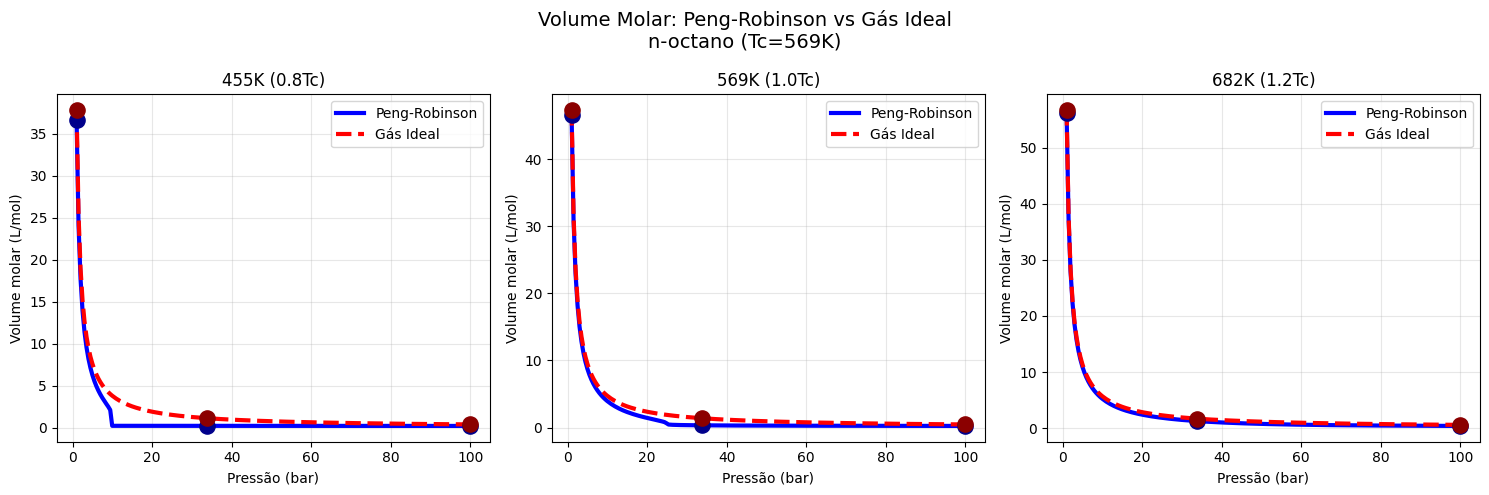

In [109]:
plotar_volume_PR_vs_ideal(df, fluido_escolhido)


# Conclusão Técnica
Através da modelagem de Peng-Robinson, observamos que para o {fluido_escolhido}, o fator de compressibilidade $Z$ atinge seu valor mínimo próximo à região crítica ($T_c$, $P_c$), onde as forças atrativas são máximas. Para o setor de engenharia, ignorar esse desvio (assumindo $Z=1$) resultaria em um erro de projeto no volume de estocagem nas condições testadas.


In [110]:

comparacao_final = []
for nome, props in fluidos.items():
    A, B = pr_params(props["Tc"], props["Pc"], props["omega"], props["Tc"], 1e7)
    Z = pr_Z_fisico(A, B)
    comparacao_final.append({"Fluido": nome, "Tc(K)": props["Tc"], "Z Tc,100bar": round(Z,3)})
pd.DataFrame(comparacao_final)


,Fluido,Tc(K),"Z Tc,100bar"
0,metano,190.6,0.333
1,etano,305.3,0.319
2,propano,369.8,0.353
3,n-butano,425.2,0.384
4,n-pentano,469.7,0.421
5,n-hexano,507.6,0.456
6,n-heptano,540.2,0.494
7,n-octano,568.7,0.533


Z Tc,100bar = "Fator de compressibilidade Z calculado na temperatura crítica (Tc) e pressão de 100 bar"

Z menor = fluido mais desviado do ideal

Hidrocarbonetos pesados (maior Tc) → mais próximos do ideal